# Compulsory Assignment 2: Convolutional neural networks

Please fill out the group name, number, members and optionally the name below.

**Group number**: 20\
**Group member 1**: Oskar Støre\
**Group member 2**: Magnus Lundetræ Fidje\
**Group member 3**: Håkon Skramstad\
**Group name (optional)**: 


# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. 


# Introduction 
This assignment will start with classifying handwritten digits from the MNIST dataset, used in the voluntary assignment and the first compulsory assignment. The second part of this task will revolve around classifying the open-source Fashion-MNIST.



## Fashion-MNIST

The Fashion-MNIST is a dataset created from Zalando's article images(https://github.com/zalandoresearch/fashion-mnist/blob/master/README.md). The dataset consists of 70,000 labels images in 28x28 grayscale image labeled from 0 to 10. The goal of the Fashion-MNIST to work as a harder version of the handletter dataset MNIST. The Github repo for the dataset describe the dataset to be:
- "intend Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms."


<center><img src="fashion-mnist-sprite.png" width="500" height="400"></center>


# LeNet-5 Architecture Overview

**LeNet-5** (LeCun et al., 1998) is a foundational Convolutional Neural Network (CNN) designed for handwritten digit classification (MNIST). It established the classic deep learning workflow: alternating **Convolution** and **Pooling** layers to extract spatial features, followed by **Dense** layers for classification.

---

## 1. Network Pipeline

$$\text{Input Image} \longrightarrow \text{Conv1} \longrightarrow \text{Pool1} \longrightarrow \text{Conv2} \longrightarrow \text{Pool2} \longrightarrow \text{Flatten} \longrightarrow \text{FC1} \longrightarrow \text{FC2} \longrightarrow \text{Output}$$

---

## 2. Layer Specification Table

| Layer | Type | Configuration / Parameters | Activation |
| :--- | :--- | :--- | :--- |
| **C1** | Conv2D | 6 filters ($5 \times 5$), Padding='same' | `tanh` |
| **S2** | AvgPooling | Window: $2 \times 2$, Stride: 2 | — |
| **C3** | Conv2D | 16 filters ($5 \times 5$), Padding='valid' | `tanh` |
| **S4** | AvgPooling | Window: $2 \times 2$, Stride: 2 | — |
| **Flatten** | Reshape | Converts feature maps to 1D vector | — |
| **F5** | Dense | 120 neurons | `tanh` |
| **F6** | Dense | 84 neurons | `tanh` |
| **Output** | Dense | 10 neurons (Classes 0–9) | `softmax` |

---

## 3. Key Concepts for Students

* **Hierarchical Feature Extraction:** Early layers extract simple visual features (edges and lines), while deeper layers combine them into complex shapes (loops and intersections).
* **Spatial Invariance:** Subsampling (Pooling) reduces feature map resolution, making the model resilient to minor shifts or rotations in input images.
* **Evolution to Modern CNNs:**
  * **Activations:** Replaced historical `tanh` with `ReLU` to eliminate vanishing gradients.
  * **Pooling:** Replaced `AveragePooling` with `MaxPooling` for stronger feature selection.
  * **Normalization:** Added `BatchNorm` after convolution operations to accelerate convergence and stabilize training.
## Assignment structure

1. Part 1: Implementing LeNet for classifying MNIST.
2. Part 2: Designing your own CNN for classifying Fashion-MNIST
 

```python
prediction = model.predict(X_test)
flat_prediction = np.argmax(prediction, axis=1) # Flatten softmax predictions
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_prediction)) # The submission csv file must have an row index column called 'ID'
submissionDF['Prediction'] = flat_prediction
submissionDF.to_csv('submission.csv', index=False) # Remember to store the dataframe to csv without the nameless index column.
```

## Library imports

In [1]:
# Feel free to add or remove libraries as you want
import time

import numpy as np
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow.keras as ks

SEED = 458
RNG = np.random.default_rng(SEED) # Random number generator

from utilities import *

I0000 00:00:1791311043.128921    9430 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791311043.129513    9430 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791311043.162454    9430 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791311044.063241    9430 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Part 1: CNN for classifying the MNIST dataset

## Loading MNIST

In [2]:
datasets = load_mnist(verbose=0)
X_train, y_train = datasets['X_train'], datasets['y_train']
X_val,   y_val   = datasets['X_val'],   datasets['y_val']
X_test,  y_test  = datasets['X_test'],  datasets['y_test']

X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0).astype('int32')

del datasets, X_val, y_val # Good to reduce uneccesary RAM usage

## Preprocessing

In [3]:
# Reshape data to account for color channel
X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)

# Normalizing input between [0,1]
X_train = X_train.astype("float32")/np.max(X_train)
X_test  = X_test.astype("float32")/np.max(X_test)

# Converting targets from numbers to categorical format
y_train = ks.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test  = ks.utils.to_categorical(y_test, len(np.unique(y_test)))

## Task 1.1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture according to the previous specifications: 

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [11]:
# import f1-score
f1score = ks.metrics.F1Score(average='macro', name='f1_score')

In [6]:
model = ks.Sequential()

model.add(ks.layers.Conv2D(
    filters=6, kernel_size=(5,5),
    padding='same', name='Conv1',
    activation='tanh'
))

model.add(ks.layers.AvgPool2D(
    pool_size =(2,2), strides =(2,2),
    name= 'Pool1'
))

model.add(ks.layers.Conv2D(
    filters=16, kernel_size=(5,5),
    padding='valid', name='Conv2',
    activation='tanh'
))

model.add(ks.layers.AvgPool2D(
    pool_size=(2,2), strides=(2,2)
))

# flatten before giving to nn
model.add(ks.layers.Flatten())

model.add(ks.layers.Dense(
    units=120, name='FC1',
    activation='tanh'
))

model.add(ks.layers.Dense(
    units=84, name='FC2',
    activation='tanh'
))

model.add(ks.layers.Dense(
    units=10, name='Output',
    activation='softmax'
))

### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs
* 1/8 validation split

In [13]:
# don't need to specify batch size
model.build(input_shape=(None, 28, 28, 1))

model.compile(
    optimizer=ks.optimizers.Adam(),
    loss= ks.losses.CategoricalCrossentropy(),
    metrics= ['accuracy', f1score]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (AveragePooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(X_train, y_train, batch_size=64, epochs=20, validation_split=1/8)

Epoch 1/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9155 - f1_score: 0.9145 - loss: 0.2871 - val_accuracy: 0.9591 - val_f1_score: 0.9586 - val_loss: 0.1362
Epoch 2/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9688 - f1_score: 0.9686 - loss: 0.1036 - val_accuracy: 0.9728 - val_f1_score: 0.9726 - val_loss: 0.0870
Epoch 3/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9789 - f1_score: 0.9788 - loss: 0.0692 - val_accuracy: 0.9800 - val_f1_score: 0.9799 - val_loss: 0.0691
Epoch 4/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9846 - f1_score: 0.9845 - loss: 0.0509 - val_accuracy: 0.9769 - val_f1_score: 0.9767 - val_loss: 0.0743
Epoch 5/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9867 - f1_score: 0.9867 - loss: 0.0413 - val_accuracy: 0.9821 - val_f1_score: 0.9819 - val_loss: 0.0624
Epoch 6/20
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9896 - f1_score: 0.9895 - loss: 0.0323 - val_accuracy: 0.9813 - val_f1_score: 0.9811

## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history and evaluate on test dataset

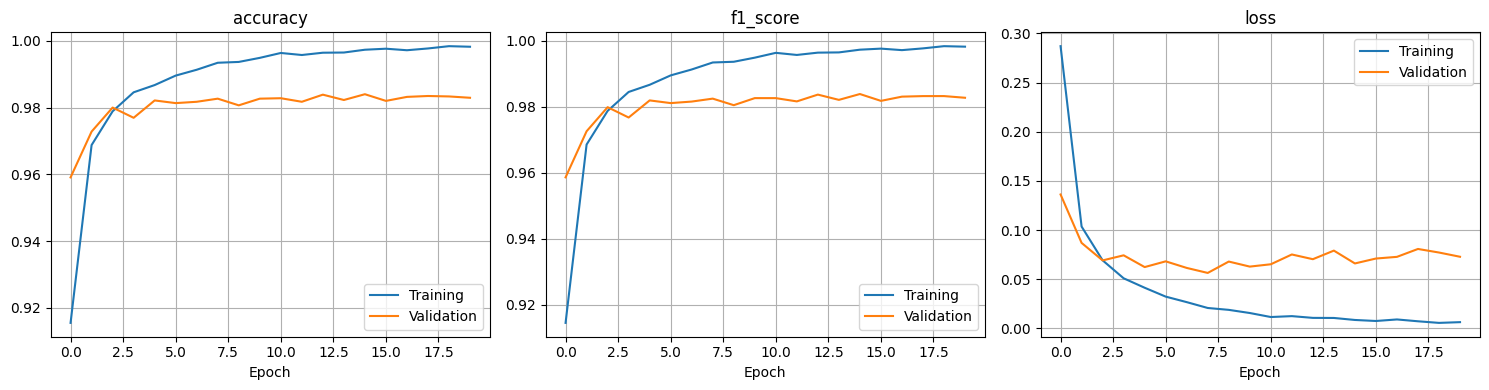

In [15]:
plot_training_history(history)

### Task 1.2.2 Evaluate on the test dataset

In [16]:
evaluate = model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9855 - f1_score: 0.9854 - loss: 0.0592


### Task 2.2.3 Create a confution matrix for both traing and testing data
- Does the test data and train data predikt the same items wrong?

## Task 2.3: MNIST discussion

**Task 2.3.1: What is overfitting and how does it occur during training of the LeNet-5 model**

**Task 2.3.2: What is ReLU and Leaky ReLU, what is their derivative and how does their derivative solve the vanishing gradient problem?**

**Task 2.3.3: Calculate the numbers of weight and the output shape for the LeNet-5 at each layer, Show calculation**

# Task 2: CNN for classifying the Fashion-MNIST dataset

In this task you shall implement a CNN model, and train it to classify the images in the Fashion-MNIST dataset.

## Importing Fashion-MNIST

- Filename: `Fashion_MNIST.h5`

In [8]:
# Change this path
path = r"C:\Users\alfa\OneDrive - Norwegian University of Life Sciences\Desktop\AML_NMBU\DAT300\DAT300_2025\CA2_CNN_Template-1\Template\Fashion_MNIST.h5"
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot" 
}

In [10]:
# 2. Use 'path' variable here
with h5py.File(path, 'r') as f:
    print('Datasets in file:', list(f.keys()))
    X_train = np.asarray(f['train_images'])
    y_train = np.asarray(f['train_labels'])
    X_test  = np.asarray(f['test_images'])
    print('Nr. train images: %i' % (X_train.shape[0]))
    print('Nr. test images: %i' % (X_test.shape[0]))

Datasets in file: ['test_images', 'train_images', 'train_labels']
Nr. train images: 59500
Nr. test images: 10500


## Task 2.1: Preprocess the data
Preprocess the data as you see fit

## Task 2.2: Visualize the dataset
Plot a few samples images and the distrbution of classes in the data. 

## Task 2.3: Build a CNN for classifying the Fashion-MNIST dataset
Build a CNN model 
- Experiment with different, Kernel sizes, stride, type/number of layers. 
- Don't overcomplicate and use it as grounds for discussion. 
- Tips, when you make changes to improve the model, save some earlier iterations.
- Only one model score higher than beat me.

# Task 2.5: Fashion-MNIST Discussion

### Task 3.5.1
- Feel Free to experiment on architecture
- Comment on the choice of layers and hyperparameters. 
    - Did you find some different results in changing a hyperparameter or add/remove a layer.
